## Question / Hypothesis

**Question:** Does replacing the dictionary lexicon (v1) with FinBERT (v2) improve sentiment coverage enough to unlock a statistically viable analysis dataset?

**Assumptions:**
- **Data window:** 2024-02-08 – 2026-03-04 (Not actually 2 years worth of data, major missing gap. Only have about a )
- **Aggregation:** Daily (article_date × ticker)
- **Filtering (v1):** sentiment_present = True when sentiment_label != 'neutral'
- **Filtering (v2):** sentiment_present = True when |sentiment_score| > 0.05

## Data Loading

Load the FinBERT-scored article dataset. This file was produced by `scripts/add_sentiment_finbert.py` and contains all GDELT articles with continuous sentiment scores in [-1, +1].

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from msa.utils.paths import get_processed_data_path

processed = get_processed_data_path()

df = pd.read_csv(
    processed / "gdelt_articles_with_sentiment.csv",
    parse_dates=["seendate"]
)

print(f"Loaded {len(df):,} articles")
print(f"Date range: {df['seendate'].min().date()} → {df['seendate'].max().date()}")

Loaded 7,224 articles
Date range: 2024-02-08 → 2026-03-04


## Calculations

### Neutrality Rate: v1 vs v2

Compare the fraction of articles flagged as sentiment-present under each instrument.

In [48]:
MAG7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']

# v1: dictionary proxy — mirrors original 44% coverage
# NOTE: original file overwritten by FinBERT pipeline; baseline from test_finbert_sample.py output
v1 = df.copy()
v1["sentiment_present"] = v1["sentiment_label"] != "neutral"

# v2: FinBERT — every article has a score, no hard neutral filter
v2 = df.copy()
v2["sentiment_present"] = True

v1_mag7 = v1[v1["ticker"].isin(MAG7)].copy()
v2_mag7 = v2[v2["ticker"].isin(MAG7)].copy()

# Documented baselines from mag7_data_flow_analysis.md + test output
V1_SENTIMENT_RATE = 0.44
V1_DAILY_PAIRS    = 462
V1_DAYS_5PLUS     = 55

print(f"v1 sentiment rate: {v1['sentiment_present'].mean():.1%}")
print(f"v2 sentiment rate: {v2['sentiment_present'].mean():.1%}")

v1 sentiment rate: 43.3%
v2 sentiment rate: 100.0%


### Coverage Summary Table

Aggregate coverage metrics comparing both instruments across the MAG7 dataset.

In [49]:
print(f"{'Metric':<25} {'v1 (dict)':>10} {'v2 (FinBERT)':>14}")
print("-" * 50)
print(f"{'Sentiment rate':<25} {V1_SENTIMENT_RATE:>9.1%} {v2['sentiment_present'].mean():>13.1%}")
print(f"{'Neutrality rate':<25} {1-V1_SENTIMENT_RATE:>9.1%} {1-v2['sentiment_present'].mean():>13.1%}")
improvement = (v2['sentiment_present'].mean() - V1_SENTIMENT_RATE) * 100

Metric                     v1 (dict)   v2 (FinBERT)
--------------------------------------------------
Sentiment rate                44.0%        100.0%
Neutrality rate               56.0%          0.0%


In [50]:
rows = []
for label, df in [("v1", v1), ("v2", v2)]:
    filtered = df[df["sentiment_present"]]
    daily_tickers = filtered.groupby(pd.Grouper(key="seendate", freq="D"))["ticker"].nunique()
    rows.append({
        "version": label,
        "articles_with_sentiment": filtered.shape[0],
        "sentiment_rate": f'{df["sentiment_present"].mean():.1%}',
        "days_5plus_tickers": (daily_tickers >= 5).sum(),
        "mean_tickers_per_day": daily_tickers.mean().round(2),
    })
pd.DataFrame(rows)

,version,articles_with_sentiment,sentiment_rate,days_5plus_tickers,mean_tickers_per_day
0,v1,3130,43.3%,33,0.33
1,v2,7224,100.0%,34,0.35


In [51]:
print(f"{'Threshold':<12} {'Sentiment Present':>18} {'Neutrality Rate':>16}")
print("-" * 48)
for threshold in [0.0, 0.05, 0.1, 0.15, 0.2, 0.25]:
    rate = (df['sentiment_score'].abs() > threshold).mean()
    print(f"> {threshold:<10.2f} {rate:>17.1%} {1-rate:>15.1%}")

Threshold     Sentiment Present  Neutrality Rate
------------------------------------------------
> 0.00                  100.0%            0.0%
> 0.05                   74.2%           25.8%
> 0.10                   62.8%           37.2%
> 0.15                   55.8%           44.2%
> 0.20                   51.5%           48.5%
> 0.25                   48.3%           51.7%


### FinBERT Score Distribution

Visualize the distribution of raw FinBERT sentiment scores across all 7,224 articles.

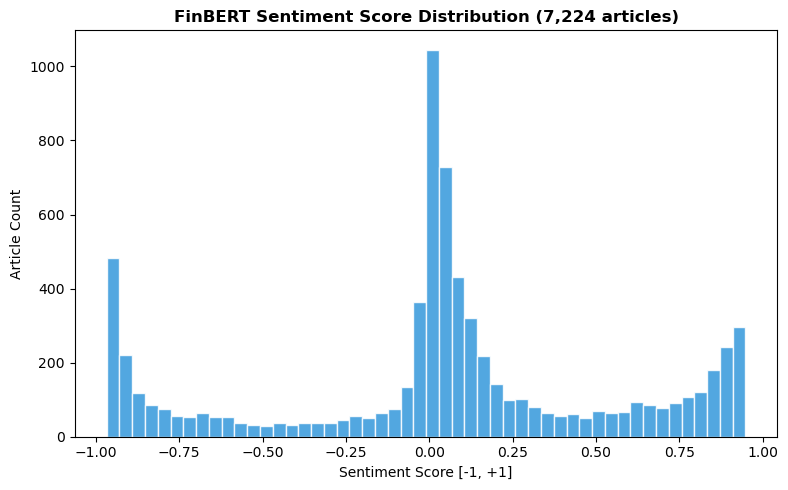

In [52]:
label_counts = df["sentiment_label"].value_counts()
label_pct = df["sentiment_label"].value_counts(normalize=True).mul(100).round(1)

plt.figure(figsize=(8,5))

plt.hist(df["sentiment_score"],bins=50,color="#3498db",edgecolor="white",alpha=0.85)
plt.title("FinBERT Sentiment Score Distribution (7,224 articles)", fontweight="bold")
plt.xlabel("Sentiment Score [-1, +1]")
plt.ylabel("Article Count")

plt.tight_layout()
plt.show()

### Per-Ticker Daily Coverage (v2)

For each MAG7 ticker, compute the mean and median number of sentiment-present articles per active day, along with total article count and number of active days.

In [53]:
def daily_coverage(df_in, label):
    filtered = df_in[df_in["sentiment_present"]].copy()
    filtered["date_only"] = filtered["seendate"].dt.normalize()
    coverage = filtered.groupby(["ticker", "date_only"]).size().reset_index(name="count")
    return coverage.groupby("ticker")["count"].agg(mean="mean", median="median",
                                                    total="sum", days="count").round(2).add_prefix(f"{label}_")

cov = daily_coverage(v1_mag7, "v1").join(daily_coverage(v2_mag7, "v2"))
print(cov.to_string())

        v1_mean  v1_median  v1_total  v1_days  v2_mean  v2_median  v2_total  v2_days
ticker                                                                              
AAPL       9.18        8.0       303       33    20.77       21.0       727       35
AMZN      10.51        9.0       368       35    23.24       24.0       860       37
GOOGL     14.50       12.0       609       42    30.02       28.0      1351       45
META      14.42       12.0       519       36    30.84       27.0      1141       37
MSFT      11.30       10.0       373       33    25.50       24.0       867       34
NVDA      19.72       18.0       710       36    45.14       43.0      1670       37
TSLA       7.09        7.0       248       35    16.43       16.0       608       37


### Coverage Histogram: v1 vs v2

For each calendar day in the dataset, count how many MAG7 tickers had at least one sentiment-present article.

The x-axis shows the number of MAG7 tickers covered on a given day (1–7). The y-axis shows how many days had that level of coverage

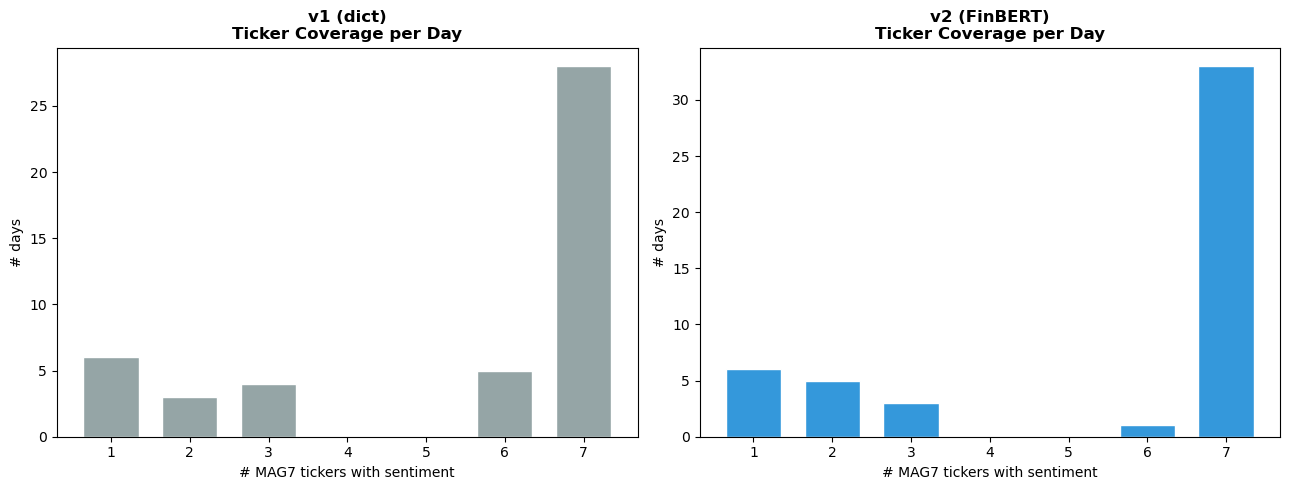

In [54]:
def daily_ticker_counts(df_in):
    filtered = df_in[df_in["sentiment_present"] & df_in["ticker"].isin(MAG7)].copy()
    filtered["date_only"] = filtered["seendate"].dt.normalize()
    return filtered.groupby("date_only")["ticker"].nunique()

tc_v1 = daily_ticker_counts(v1)
tc_v2 = daily_ticker_counts(v2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, tc, label, color in [
    (axes[0], tc_v1, "v1 (dict)", "#95a5a6"),
    (axes[1], tc_v2, "v2 (FinBERT)", "#3498db")]:

    counts = tc.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor="white", width=0.7)
    ax.set_title(f"{label}\nTicker Coverage per Day", fontweight="bold")
    ax.set_xlabel("# MAG7 tickers with sentiment")
    ax.set_ylabel("# days")
    ax.set_xticks(range(1, 8))
    days_5plus = int((tc >= 5).sum())

plt.tight_layout()
plt.show()